In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

parent_folder= 'D:/Research/DIC'

samples = [f'S{n}' for n in [1,2,3]]
loadsteps = ['5']
values = ['Exx', 'Eyy', 'Exy']

for sample in samples:
    for side in ['A', 'B']:
        folder = f"{parent_folder}/{sample}/{side}"
        all_csvs = [f for f in os.listdir(folder) if f.endswith('.csv')]

        for ls in loadsteps:
            ls_csvs = [f for f in all_csvs if f.startswith(f'{ls}k')]

            for value in values:
                selected_csvs = [f for f in ls_csvs if value in f]

                stack = []
                for csv in selected_csvs:
                    data = np.genfromtxt(f'{folder}/{csv}', delimiter=',')
                    stack.append(data)

                stack = np.array(stack)  # shape: (n_images, H, W)
                # Mask of valid (nonzero) entries
                mask = stack != 0

                # Sum only nonzero values
                summed = np.sum(stack * mask, axis=0)
                # Count nonzero entries per pixel
                counts = np.sum(mask, axis=0)
                # Avoid division by zero
                avg = np.divide(summed, counts, where=counts != 0)

                # Optional: set pixels with no valid values to 0 or NaN
                avg[counts == 0] = np.nan
                np.save(f'DIC/{sample}{side}_{ls}k_{value}_avg.npy', avg)

(26, 4160, 6240)
(4160, 6240)
(4160, 6240)
(4160, 6240)


C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_1533940\3543604346.py:39: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  avg = np.divide(summed, counts, where=counts != 0)


(26, 4160, 6240)
(4160, 6240)
(4160, 6240)
(4160, 6240)
(26, 4160, 6240)
(4160, 6240)
(4160, 6240)
(4160, 6240)
(26, 4160, 6240)
(4160, 6240)
(4160, 6240)
(4160, 6240)
(26, 4160, 6240)
(4160, 6240)
(4160, 6240)
(4160, 6240)
(26, 4160, 6240)
(4160, 6240)
(4160, 6240)
(4160, 6240)
(24, 4160, 6240)
(4160, 6240)
(4160, 6240)
(4160, 6240)
(24, 4160, 6240)
(4160, 6240)
(4160, 6240)
(4160, 6240)
(24, 4160, 6240)
(4160, 6240)
(4160, 6240)
(4160, 6240)
(24, 4160, 6240)
(4160, 6240)
(4160, 6240)
(4160, 6240)
(24, 4160, 6240)
(4160, 6240)
(4160, 6240)
(4160, 6240)
(24, 4160, 6240)
(4160, 6240)
(4160, 6240)
(4160, 6240)


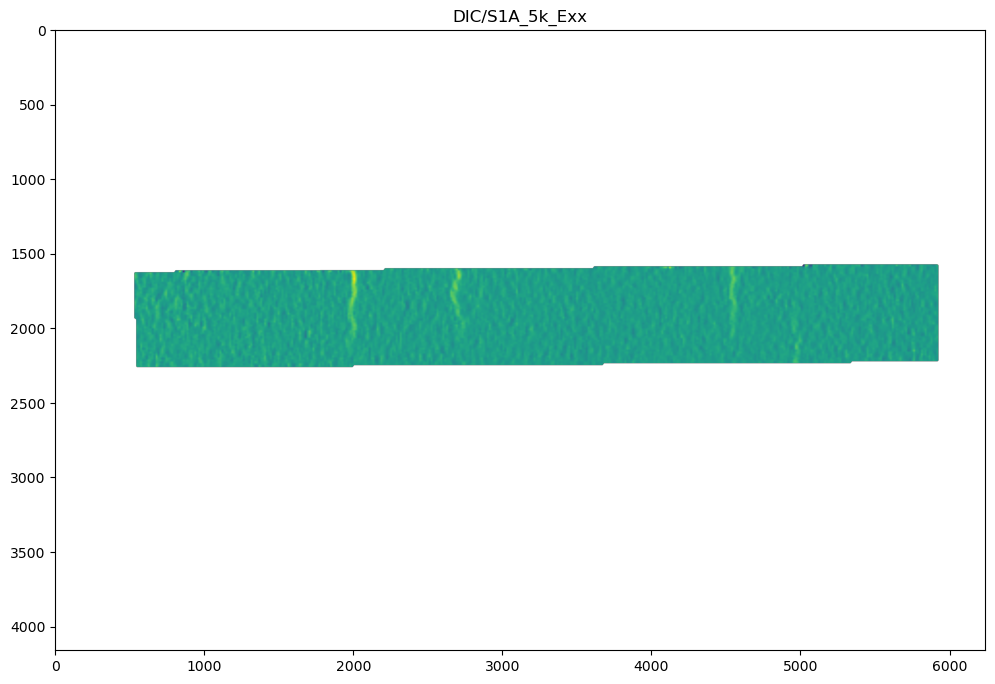

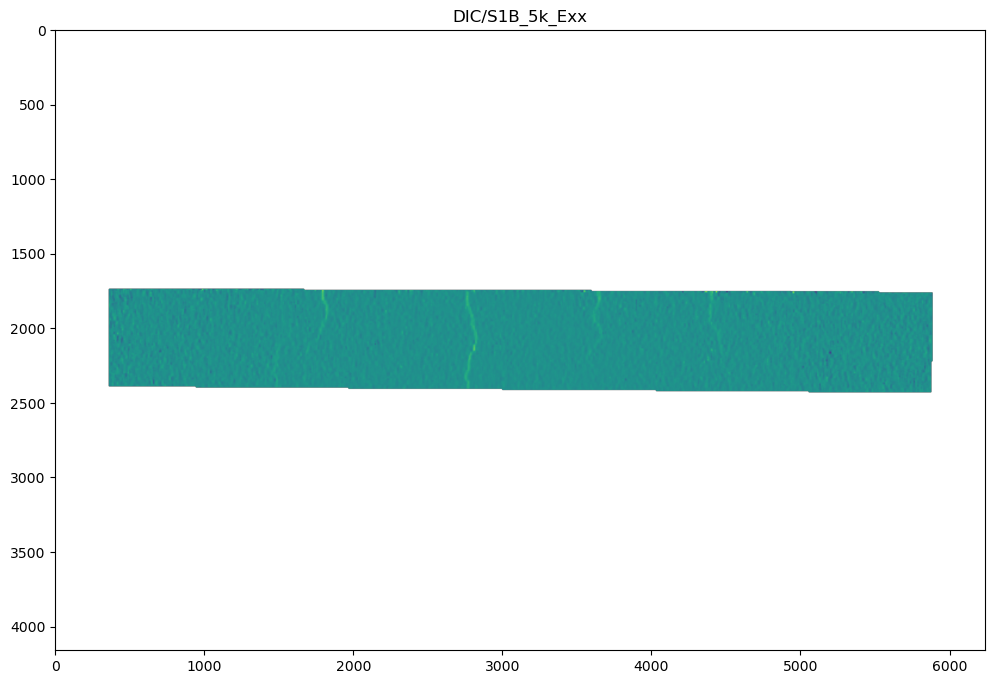

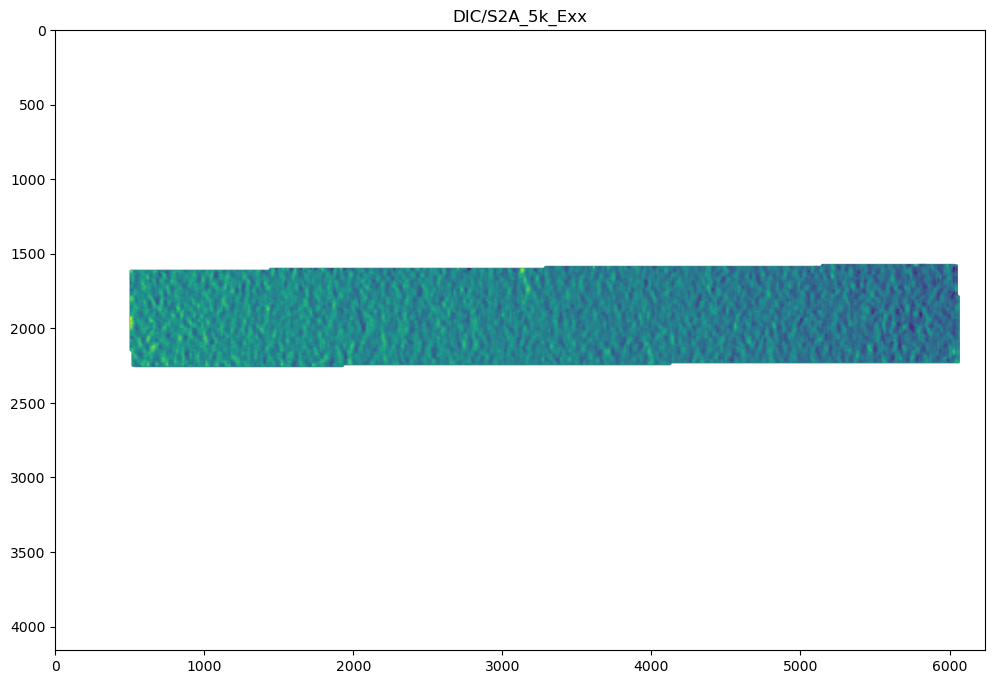

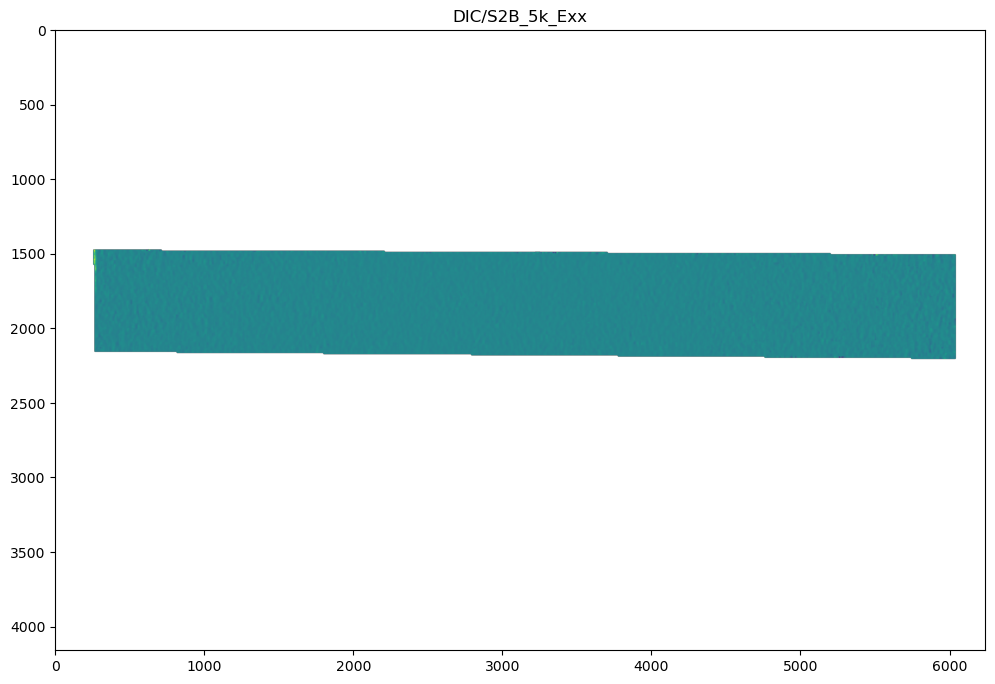

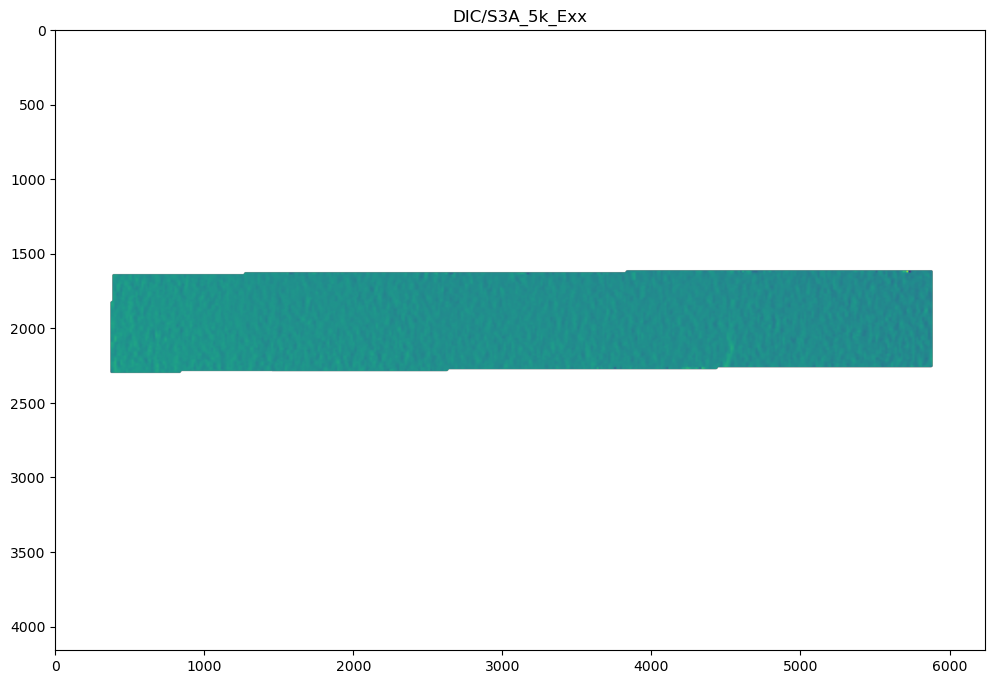

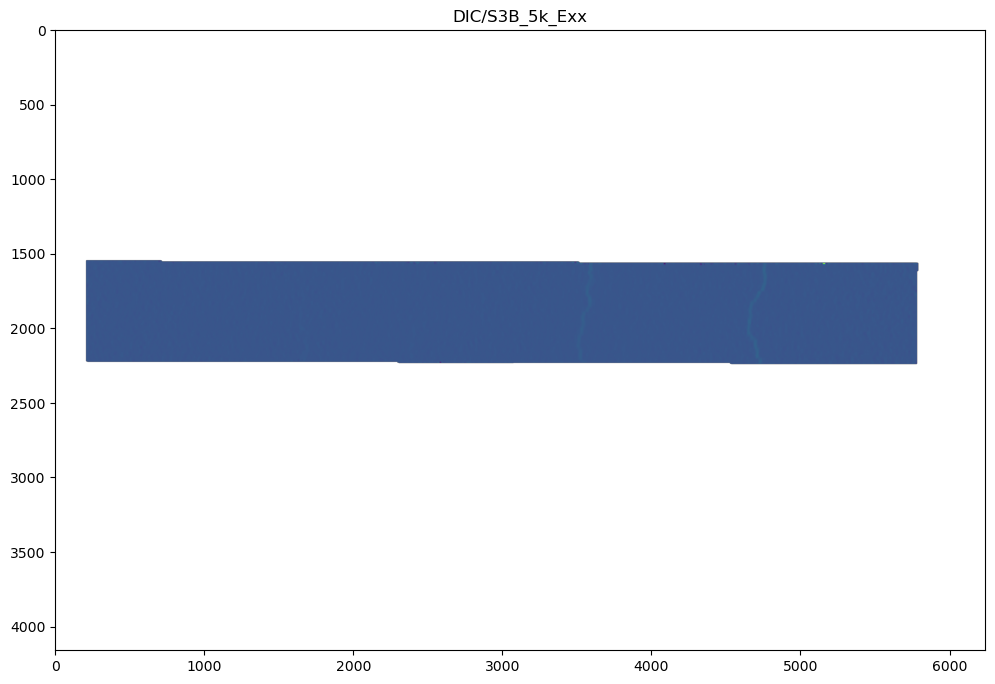

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import os

parent_folder= 'D:/Research/DIC'

samples = [f'S{n}' for n in [1,2,3]]
loadsteps = ['5']
values = ['Exx', 'Eyy', 'Exy']

for sample in samples:
    for side in ['A', 'B']:
        folder = f"{parent_folder}/{sample}/{side}"
        all_csvs = [f for f in os.listdir(folder) if f.endswith('.csv')]

        for ls in loadsteps:
            ls_csvs = [f for f in all_csvs if f.startswith(f'{ls}k')]

            for value in values:
                if value == 'Exx':
                    data = np.load(f'DIC/{sample}{side}_{ls}k_{value}_avg.npy')
                    plt.figure(figsize=(12,12))
                    plt.imshow(data)
                    plt.title(f'DIC/{sample}{side}_{ls}k_{value}')
                    plt.show()

In [ ]:
# take bottom right hand corner of A side to be origin
import numpy as np
import matplotlib.pyplot as plt
import os

parent_folder= 'D:/Research/DIC'

samples = [f'S{n}' for n in [1,2,3]]
loadsteps = ['5']
values = ['Exx', 'Eyy', 'Exy']

for sample in samples:
    for side in ['A', 'B']:
        folder = f"{parent_folder}/{sample}/{side}"
        all_csvs = [f for f in os.listdir(folder) if f.endswith('.csv')]

        for ls in loadsteps:
            ls_csvs = [f for f in all_csvs if f.startswith(f'{ls}k')]

            for value in values:
                data = np.load(f'DIC/{sample}{side}_{ls}k_{value}_avg.npy')

                if side == 'A':
                    data_reshape = np.flip(data, axis=(0,1))
                if side == 'B':
                    data_reshape = np.flip(data, axis=(0))
                np.save(f'DIC/{sample}{side}_{ls}k_{value}_reshape.npy', data_reshape)

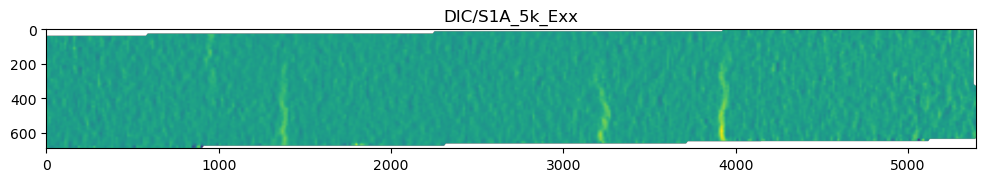

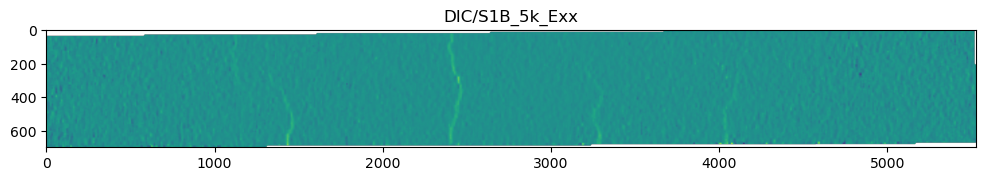

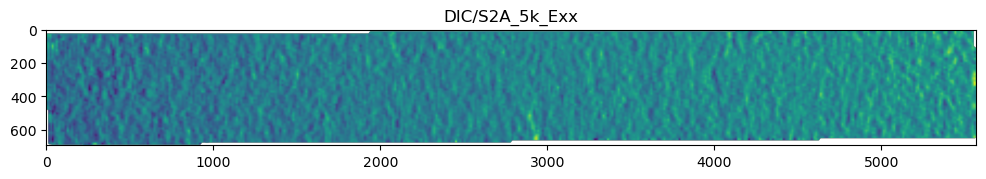

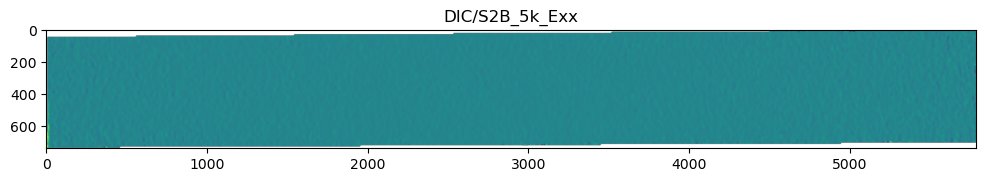

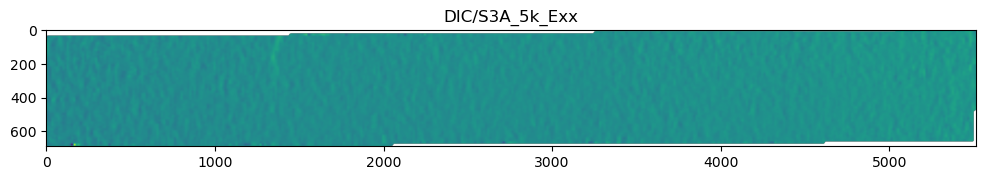

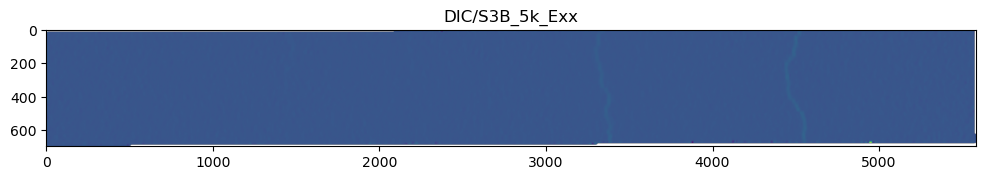

In [106]:
# take bottom right hand corner of A side to be origin
import numpy as np
import matplotlib.pyplot as plt
import os

parent_folder= 'D:/Research/DIC'

samples = [f'S{n}' for n in [1,2,3]]
loadsteps = ['5']
values = ['Exx', 'Eyy', 'Exy']

for sample in samples:
    for side in ['A', 'B']:
        folder = f"{parent_folder}/{sample}/{side}"
        all_csvs = [f for f in os.listdir(folder) if f.endswith('.csv')]

        for ls in loadsteps:
            ls_csvs = [f for f in all_csvs if f.startswith(f'{ls}k')]

            for value in values:

                data = np.load(f'DIC/{sample}{side}_{ls}k_{value}_reshape.npy')

                valid_mask = ~np.isnan(data)

                # Rows and columns that contain at least one valid value
                rows = np.any(valid_mask, axis=1)
                cols = np.any(valid_mask, axis=0)
                data_crop = data[rows][:, cols]
                if value == 'Exx':
                    plt.figure(figsize=(12,12))
                    plt.imshow(data_crop)
                    plt.title(f'DIC/{sample}{side}_{ls}k_{value}')
                    plt.show()
                np.save(f'DIC/{sample}{side}_{ls}k_{value}_reshape_crop.npy', data_crop)

Exx, Best angle: -0.450 degrees


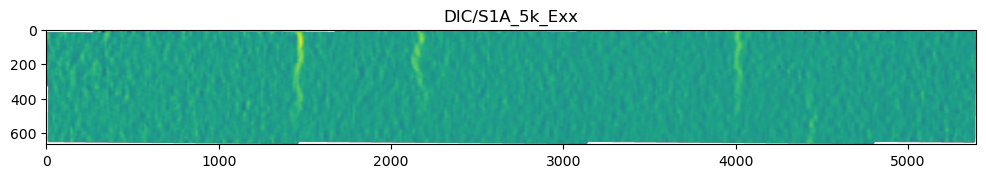

Eyy, Best angle: -0.450 degrees
Exy, Best angle: -0.450 degrees
Exx, Best angle: 0.280 degrees


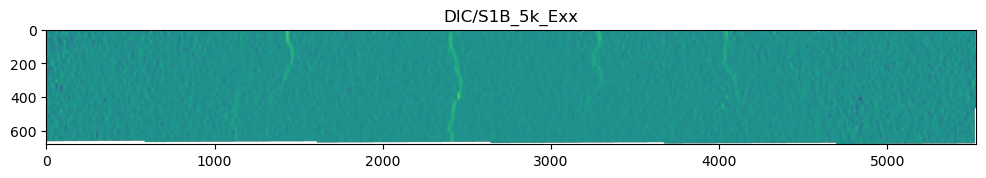

Eyy, Best angle: 0.280 degrees
Exy, Best angle: 0.280 degrees
Exx, Best angle: -0.370 degrees


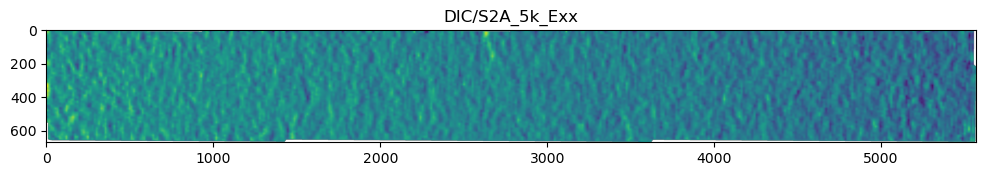

Eyy, Best angle: -0.370 degrees
Exy, Best angle: -0.370 degrees
Exx, Best angle: 0.290 degrees


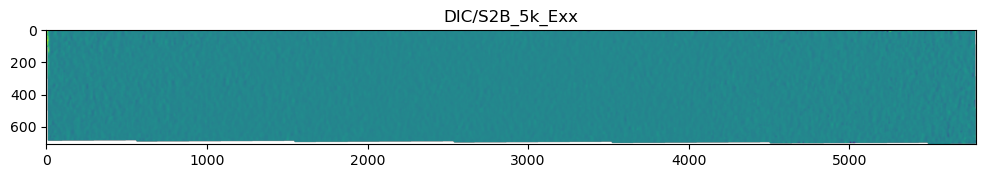

Eyy, Best angle: 0.290 degrees
Exy, Best angle: 0.290 degrees
Exx, Best angle: -0.320 degrees


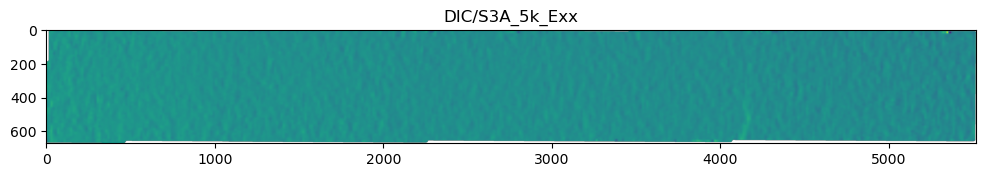

Eyy, Best angle: -0.320 degrees
Exy, Best angle: -0.320 degrees
Exx, Best angle: 0.160 degrees


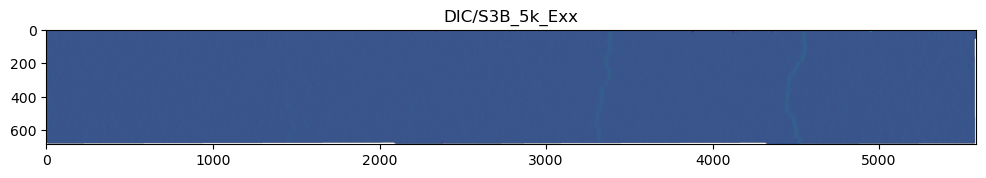

Eyy, Best angle: 0.160 degrees
Exy, Best angle: 0.160 degrees


In [107]:
import numpy as np
from scipy.ndimage import rotate
import json

def best_rotation_min_nan(img, angle_range=(-0.6, 0.3), angle_step=0.01):
    best_angle = 0
    best_score = np.inf
    best_img = img

    for angle in np.arange(angle_range[0], angle_range[1], angle_step):
        rotated = rotate(img, angle, reshape=True, order=1, mode='constant', cval=np.nan)

        # Count NaNs (lower is better)
        valid_mask = ~np.isnan(rotated)

        # Rows and columns that contain at least one valid value
        rows = np.any(valid_mask, axis=1)
        cols = np.any(valid_mask, axis=0)
        data_crop = rotated[rows][:, cols]
        nan_count = np.isnan(data_crop[:,5:-5]).sum()

        if nan_count < best_score:
            best_score = nan_count
            best_angle = angle
            best_img = data_crop

    return best_img, best_angle

samples = ['S1', 'S2', 'S3']
loadsteps = ['5']
values = ['Exx', 'Eyy', 'Exy']
rotation_dict = {}
for sample in samples:
    for side in ['A', 'B']:
        folder = f"{parent_folder}/{sample}/{side}"
        all_csvs = [f for f in os.listdir(folder) if f.endswith('.csv')]

        for ls in loadsteps:
            ls_csvs = [f for f in all_csvs if f.startswith(f'{ls}k')]

            for value in values:

                data = np.load(f'DIC/{sample}{side}_{ls}k_{value}_avg.npy')
                data_crop, angle = best_rotation_min_nan(data)

                print(f"{value}, Best angle: {angle:.3f} degrees")
                if value == 'Exx':
                    plt.figure(figsize=(12,12))
                    plt.imshow(data_crop)
                    plt.title(f'DIC/{sample}{side}_{ls}k_{value}')
                    plt.show()
                np.save(f'DIC/{sample}{side}_{ls}k_{value}_rotate_crop.npy', data_crop)
                rotation_dict[f'{sample}{side}_{ls}k_{value}'] = angle

with open('DIC/rotation_dict.json', 'w') as file:
    json.dump(rotation_dict, file)

In [137]:
# take bottom right hand corner of A side to be origin
import numpy as np
import matplotlib.pyplot as plt
import os

parent_folder= 'D:/Research/DIC'

samples = [f'S{n}' for n in [1,2,3]]
loadsteps = ['5']
values = ['Exx', 'Eyy', 'Exy']

for sample in samples:
    for side in ['A', 'B']:
        folder = f"{parent_folder}/{sample}/{side}"
        all_csvs = [f for f in os.listdir(folder) if f.endswith('.csv')]

        for ls in loadsteps:
            ls_csvs = [f for f in all_csvs if f.startswith(f'{ls}k')]

            for value in values:
                data = np.load(f'DIC/{sample}{side}_{ls}k_{value}_rotate_crop.npy')

                if side == 'A':
                    data_reshape = np.flip(data, axis=(1))
                if side == 'B':
                    # data_reshape = np.flip(data, axis=(0))
                    data_reshape = data
                np.save(f'DIC/{sample}{side}_{ls}k_{value}_rotate_crop_reshape.npy', data_reshape)

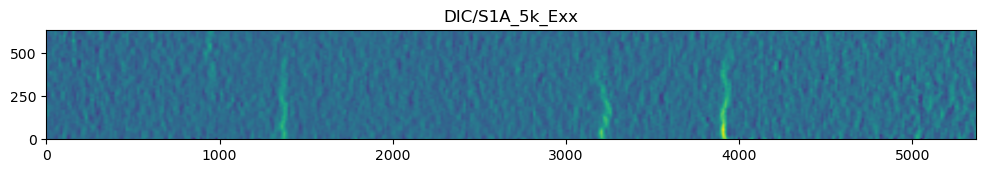

Exx (632, 5371)
Eyy (632, 5371)
Exy (632, 5371)


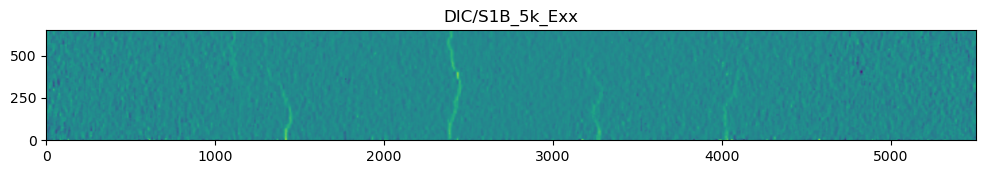

Exx (651, 5506)
Eyy (651, 5506)
Exy (651, 5506)


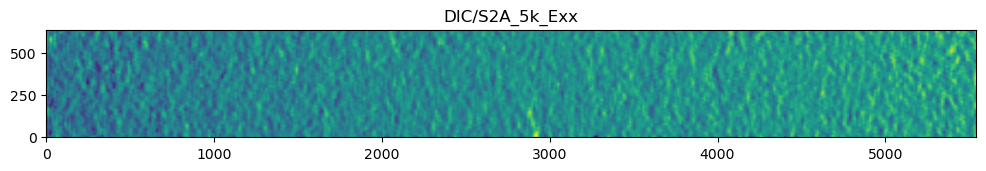

Exx (641, 5543)
Eyy (641, 5543)
Exy (641, 5543)


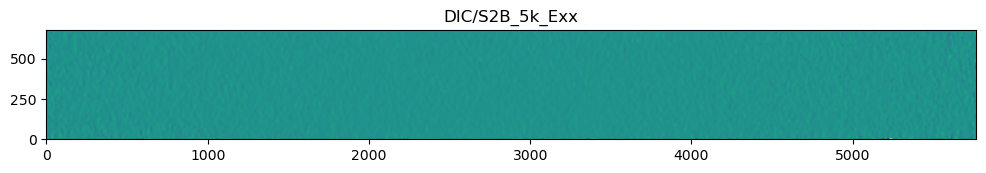

Exx (677, 5767)
Eyy (677, 5767)
Exy (677, 5767)


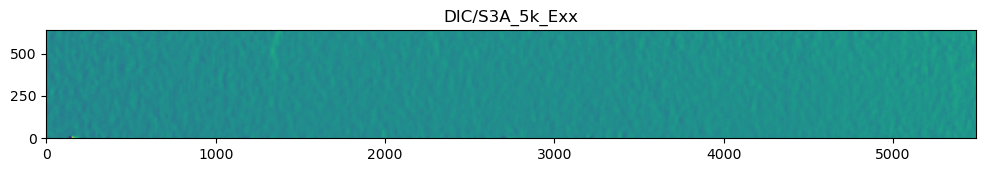

Exx (638, 5493)
Eyy (638, 5493)
Exy (638, 5493)


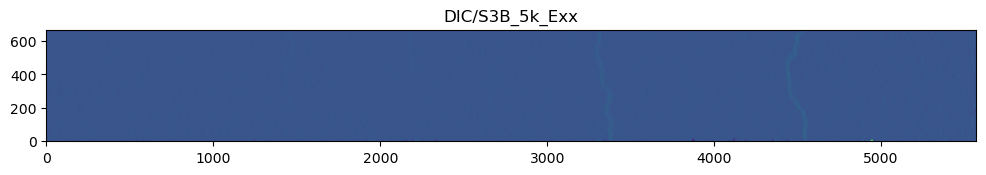

Exx (669, 5571)
Eyy (669, 5571)
Exy (669, 5571)


In [157]:
import numpy as np
def trim_edges_only(img):
    trimmed = img.copy()

    while True:
        changed = False

        # Top
        if np.isnan(trimmed[0]).any():
            trimmed = trimmed[1:]
            changed = True

        # Bottom
        if np.isnan(trimmed[-1]).any():
            trimmed = trimmed[:-1]
            changed = True

        # Left
        if np.isnan(trimmed[:, 0]).any():
            trimmed = trimmed[:, 1:]
            changed = True

        # Right
        if np.isnan(trimmed[:, -1]).any():
            trimmed = trimmed[:, :-1]
            changed = True

        if not changed:
            break

    return trimmed


samples = ['S1', 'S2', 'S3']
loadsteps = ['5']
values = ['Exx', 'Eyy', 'Exy']
rotation_dict = {}
for sample in samples:
    for side in ['A', 'B']:
        folder = f"{parent_folder}/{sample}/{side}"
        all_csvs = [f for f in os.listdir(folder) if f.endswith('.csv')]

        for ls in loadsteps:
            ls_csvs = [f for f in all_csvs if f.startswith(f'{ls}k')]

            for value in values:
                data = np.load(f'DIC/{sample}{side}_{ls}k_{value}_rotate_crop_reshape.npy')
                data_trim = trim_edges_only(data)
                if np.sum(np.isnan(data_trim)) > 0:
                    print('nan')
                if value == 'Exx':
                    plt.figure(figsize=(12,12))
                    plt.imshow(data_trim, origin='lower')
                    plt.title(f'DIC/{sample}{side}_{ls}k_{value}')
                    plt.show()
                np.save(f'DIC/{sample}{side}_{ls}k_{value}_rcr_trim.npy', data_trim)

In [172]:
# adjust values for rotation

samples = ['S1', 'S2', 'S3']
loadsteps = ['5']
values = ['Exx', 'Eyy', 'Exy']
with open("DIC/rotation_dict.json", "r") as f:
    rotation_dict = json.load(f)

for sample in samples:
    for side in ['A', 'B']:
        for ls in loadsteps:
            Exx = np.load(f'DIC/{sample}{side}_{ls}k_Exx_rcr_trim.npy')
            Eyy = np.load(f'DIC/{sample}{side}_{ls}k_Eyy_rcr_trim.npy')
            Exy = np.load(f'DIC/{sample}{side}_{ls}k_Exy_rcr_trim.npy')
            angle = np.round(rotation_dict[f'{sample}{side}_{ls}k_Exx'], 2)

            Exx_new = 0.5*(Exx+Eyy)+0.5*(Exx-Eyy)*np.cos(2*angle*np.pi/180)+Exy*np.sin(2*angle*np.pi/180)
            Eyy_new = 0.5*(Exx+Eyy)-0.5*(Exx-Eyy)*np.cos(2*angle*np.pi/180)-Exy*np.sin(2*angle*np.pi/180)
            Exy_new = -0.5*(Exx-Eyy)*np.sin(2*angle*np.pi/180)-Exy*np.cos(2*angle*np.pi/180)

            np.save(f'DIC/{sample}{side}_{ls}k_Exx_rcrt_adjust.npy', Exx_new)
            np.save(f'DIC/{sample}{side}_{ls}k_Eyy_rcrt_adjust.npy', Eyy_new)
            np.save(f'DIC/{sample}{side}_{ls}k_Exy_rcrt_adjust.npy', Exy_new)

In [196]:
samples = [f'S{n}' for n in [1,2,3]]
loadsteps = ['5']
values = ['Exx', 'Eyy', 'Exy']
for sample in samples:
    
    E_xx_A = np.load(f'DIC/{sample}A_{ls}k_Exx_rcrt_adjust.npy')
    E_xx_B = np.load(f'DIC/{sample}B_{ls}k_Exx_rcrt_adjust.npy')

    A_x = np.linspace(0,1,E_xx_A.shape[1], endpoint=True)
    A_y = np.linspace(0,0.12,E_xx_A.shape[0], endpoint=True)
    A_x, A_y = np.meshgrid(A_x, A_y)

    B_x = np.linspace(0,1,E_xx_B.shape[1], endpoint=True)
    B_y = np.linspace(0,0.12,E_xx_B.shape[0], endpoint=True)
    B_x, B_y = np.meshgrid(B_x, B_y)

    np.save(f'DIC/{sample}A_xpos', A_x)
    np.save(f'DIC/{sample}A_ypos', A_y)

    np.save(f'DIC/{sample}B_xpos', B_x)
    np.save(f'DIC/{sample}B_ypos', B_y)

    print(A_x.shape, A_y.shape)





(632, 5371) (632, 5371)
(641, 5543) (641, 5543)
(638, 5493) (638, 5493)


In [202]:
weights = [1.0, 0.0, 1.0]

f'{[int(i) for i in weights]}'

f'{weights}'

'[1.0, 0.0, 1.0]'

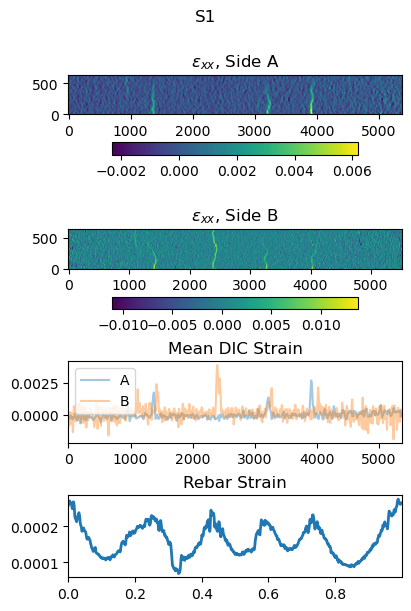

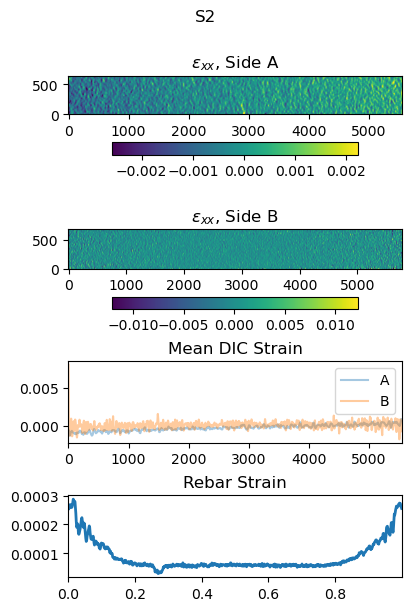

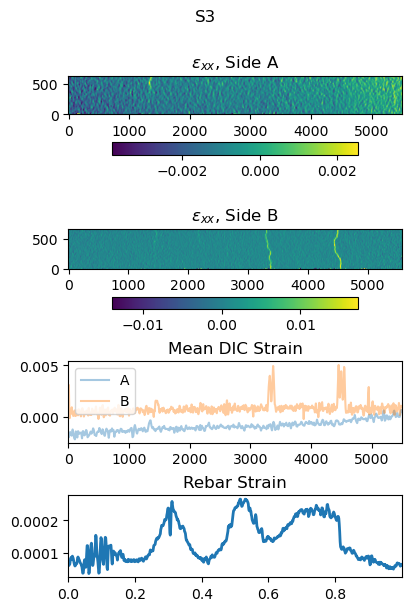

In [205]:
import numpy as np
import matplotlib.pyplot as plt

samples = [f'S{n}' for n in [1,2,3]]
loadsteps = ['5']
values = ['Exx', 'Eyy', 'Exy']

for sample in samples:
    fig, axs = plt.subplots(4, 1, figsize=(4, 6), layout='constrained')
    fig.suptitle(f'{sample}')
    
    E_xx_A = np.load(f'DIC/{sample}A_{ls}k_Exx_rcrt_adjust.npy')
    E_xx_B = np.load(f'DIC/{sample}B_{ls}k_Exx_rcrt_adjust.npy')

    strain_meas = np.load(f'rebar_strains/s{sample[-1]}_ls1_combined.npy', allow_pickle=True) * 1e-6
    strain_meas_x = np.arange(len(strain_meas)) * 0.0013

    # --- Image A ---
    vmin_A = np.sort(E_xx_A.flatten())[1000]
    vmax_A = np.sort(E_xx_A.flatten())[-1000]

    im0 = axs[0].imshow(
        E_xx_A, origin='lower',
        vmin=vmin_A, vmax=vmax_A
    )
    fig.colorbar(im0, ax=axs[0], orientation='horizontal')

    # --- Image B ---
    vmin_B = np.sort(E_xx_B.flatten())[1000]
    vmax_B = np.sort(E_xx_B.flatten())[-1000]

    im1 = axs[1].imshow(
        E_xx_B, origin='lower',
        vmin=vmin_B, vmax=vmax_B
    )
    fig.colorbar(im1, ax=axs[1], orientation='horizontal')

    # --- Mean strain plot ---
    axs[2].plot(np.mean(E_xx_A, axis=0), label='A', alpha=0.4)
    axs[2].plot(np.mean(E_xx_B, axis=0), label='B', alpha=0.4)
    axs[2].set_xlim([0, E_xx_A.shape[1]])
    axs[2].legend()

    # --- Rebar strain ---
    axs[3].plot(strain_meas_x, strain_meas, label="Measured strain", lw=2)
    axs[3].set_xlim([0, strain_meas_x[-1]])

    # Titles
    axs[0].set_title(r'$\epsilon_{xx}$, Side A')
    axs[1].set_title(r'$\epsilon_{xx}$, Side B')
    axs[2].set_title('Mean DIC Strain')
    axs[3].set_title('Rebar Strain')

    plt.show()

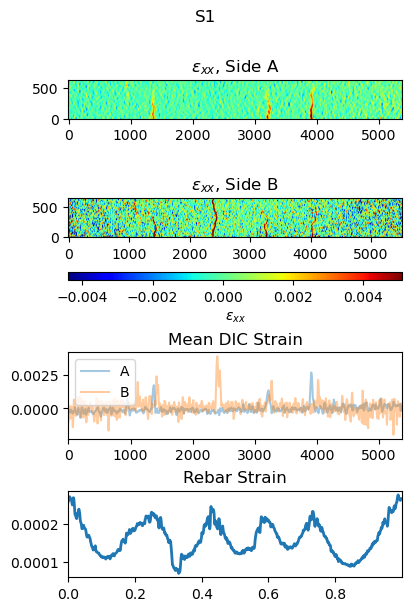

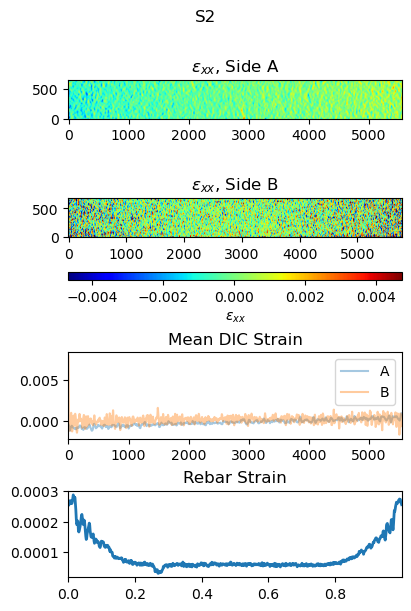

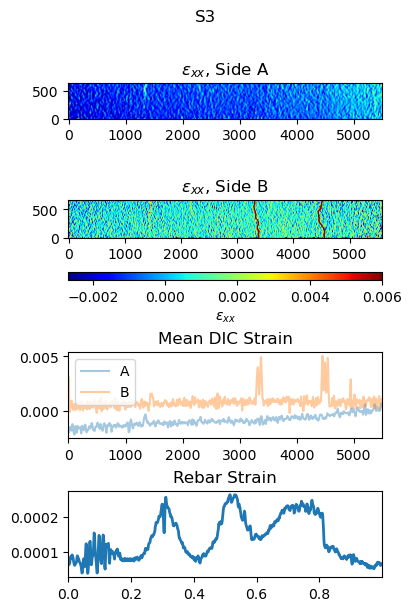

In [206]:
import numpy as np
import matplotlib.pyplot as plt

samples = [f'S{n}' for n in [1,2,3]]
loadsteps = ['5']
values = ['Exx', 'Eyy', 'Exy']

for sample in samples:
    fig, axs = plt.subplots(4, 1, figsize=(4, 6), layout='constrained')
    fig.suptitle(f'{sample}')
    
    E_xx_A = np.load(f'DIC/{sample}A_{ls}k_Exx_rcrt_adjust.npy')
    E_xx_B = np.load(f'DIC/{sample}B_{ls}k_Exx_rcrt_adjust.npy')

    strain_meas = np.load(f'rebar_strains/s{sample[-1]}_ls1_combined.npy', allow_pickle=True) * 1e-6
    strain_meas_x = np.arange(len(strain_meas)) * 0.0013

    # --- Shared color scale (robust) ---
    vmin = min(np.percentile(E_xx_A, 1), np.percentile(E_xx_B, 1))
    vmax = max(np.percentile(E_xx_A, 99), np.percentile(E_xx_B, 99))

    # --- Images ---
    im0 = axs[0].imshow(E_xx_A, origin='lower', vmin=vmin, vmax=vmax, cmap='jet')
    im1 = axs[1].imshow(E_xx_B, origin='lower', vmin=vmin, vmax=vmax, cmap='jet')

    # --- Single horizontal colorbar (shared) ---
    cbar = fig.colorbar(
        im0,
        ax=axs[:2],              # attach to both image axes
        orientation='horizontal',
        pad=0.05,
        aspect=40
    )
    cbar.set_label(r'$\epsilon_{xx}$')

    # --- Mean strain ---
    axs[2].plot(np.mean(E_xx_A, axis=0), label='A', alpha=0.4)
    axs[2].plot(np.mean(E_xx_B, axis=0), label='B', alpha=0.4)
    axs[2].set_xlim([0, E_xx_A.shape[1]])
    axs[2].legend()

    # --- Rebar strain ---
    axs[3].plot(strain_meas_x, strain_meas, label="Measured strain", lw=2)
    axs[3].set_xlim([0, strain_meas_x[-1]])

    # Titles
    axs[0].set_title(r'$\epsilon_{xx}$, Side A')
    axs[1].set_title(r'$\epsilon_{xx}$, Side B')
    axs[2].set_title('Mean DIC Strain')
    axs[3].set_title('Rebar Strain')

    plt.show()